# Handwritten Digit Recognition Project

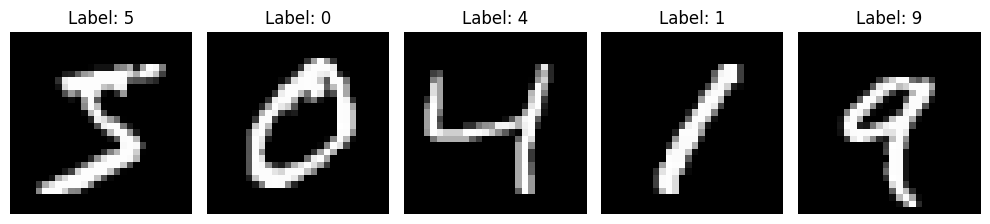

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist


(train_img, train_label), (test_img, test_label) = mnist.load_data()
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_img[i], cmap='gray')
    plt.title(f"Label: {train_label[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [95]:
from keras import models 
from keras import layers

network=models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(784,)))
network.add(layers.Dense(10, activation='softmax'))

network.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


In [96]:
train_img=train_img.reshape((60000, 28*28))
train_img=train_img.astype('float32')/255

test_img=test_img.reshape((10000, 28*28))
test_img=test_img.astype('float32')/255



# One-Hot Encoding

In [97]:
from keras.utils import to_categorical

train_label=to_categorical(train_label)
test_label=to_categorical(test_label)


# Now NN's structure is ready and we just need to train the model.

In [98]:
network.fit(train_img, train_label,batch_size=128, epochs=4)


Epoch 1/4
469/469 [==============================] - 4s 7ms/step - loss: 0.2609 - accuracy: 0.9245
Epoch 2/4
469/469 [==============================] - 4s 7ms/step - loss: 0.2609 - accuracy: 0.9245
Epoch 2/4
469/469 [==============================] - 3s 7ms/step - loss: 0.1061 - accuracy: 0.9690
Epoch 3/4
469/469 [==============================] - 3s 7ms/step - loss: 0.1061 - accuracy: 0.9690
Epoch 3/4
469/469 [==============================] - 4s 8ms/step - loss: 0.0702 - accuracy: 0.9787
Epoch 4/4
469/469 [==============================] - 4s 8ms/step - loss: 0.0702 - accuracy: 0.9787
Epoch 4/4
469/469 [==============================] - 4s 7ms/step - loss: 0.0511 - accuracy: 0.9848


In [99]:
network.evaluate(test_img,test_label, use_multiprocessing=True)


313/313 [==============================] - 1s 3ms/step - loss: 0.0672 - accuracy: 0.9783


[0.06715121865272522, 0.9782999753952026]

1/1 [==============================] - 0s 25ms/step


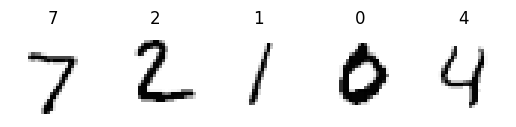

In [100]:
for index in range(5):
    plt.subplot(1, 5, index+1)
    plt.imshow(test_img[index].reshape(28,28),'Greys')
    plt.title(f'{test_label[index].argmax()}')
    result= network.predict(test_img[index].reshape(1,784),use_multiprocessing=True)
    plt.axis(False)
    # print(result.argmax())


# GUI for MNIST Prediction

In [103]:
import tkinter as tk
from tkinter import ttk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure

class ModernMNISTPredictor:
    def __init__(self, master, model, test_images, test_labels):
        self.master = master
        self.model = model
        self.test_images = test_images
        self.test_labels = test_labels
        self.max_index = len(test_images) - 1
        
        master.title('MNIST Digit Predictor')
        master.geometry('450x420')
        master.configure(bg='#f0f0f0')
        master.resizable(False, False)
        
        style = ttk.Style()
        style.theme_use('clam')
        style.configure('TFrame', background='#f0f0f0')
        style.configure('TLabel', background='#f0f0f0', font=('Segoe UI', 10))
        style.configure('TButton', font=('Segoe UI', 10), borderwidth=1)
        style.configure('Header.TLabel', font=('Segoe UI', 14, 'bold'))
        style.configure('Result.TLabel', font=('Segoe UI', 12))
        
        header_frame = ttk.Frame(master)
        header_frame.pack(fill='x', padx=20, pady=(15, 5))
        ttk.Label(header_frame, text='MNIST Digit Predictor', style='Header.TLabel').pack()
        
        input_frame = ttk.Frame(master)
        input_frame.pack(fill='x', padx=20, pady=10)
        
        input_label_frame = ttk.Frame(input_frame)
        input_label_frame.pack(fill='x', pady=5)
        ttk.Label(input_label_frame, text='Enter index (0-9999):').pack(side='left')
        
        input_entry_frame = ttk.Frame(input_frame)
        input_entry_frame.pack(fill='x')
        self.index_var = tk.StringVar()
        self.index_entry = ttk.Entry(input_entry_frame, textvariable=self.index_var, width=10, font=('Segoe UI', 10))
        self.index_entry.pack(side='left', padx=(0, 10))
        self.index_entry.insert(0, '0')  # Default value
        
        self.show_button = ttk.Button(
            input_entry_frame, 
            text='Show Image', 
            command=self.show_image,
            style='TButton'
        )
        self.show_button.pack(side='left')
        
        self.index_entry.bind('<Return>', lambda event: self.show_image())
        
        ttk.Separator(master, orient='horizontal').pack(fill='x', padx=20, pady=5)
        
        self.display_frame = ttk.Frame(master)
        self.display_frame.pack(fill='both', expand=True, padx=20, pady=10)
        
        self.info_label = ttk.Label(
            self.display_frame, 
            text='', 
            style='Result.TLabel',
            anchor='center'
        )
        self.info_label.pack(pady=5)
        
        self.fig = Figure(figsize=(3, 3), dpi=100)
        self.fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
        self.canvas = FigureCanvasTkAgg(self.fig, master=self.display_frame)
        self.canvas.get_tk_widget().pack(pady=10)
        
        self.status_var = tk.StringVar()
        self.status_var.set('Ready')
        status_bar = ttk.Label(master, textvariable=self.status_var, relief=tk.SUNKEN, anchor=tk.W)
        status_bar.pack(side=tk.BOTTOM, fill=tk.X, padx=10, pady=(0, 5))
        
        self.show_image()
    
    def show_image(self):
        try:
            self.fig.clear()
            
            self.status_var.set('Processing...')
            self.master.update_idletasks()
            
            index = int(self.index_var.get())
            
            if index < 0 or index > self.max_index:
                self.info_label.config(text=f'Error: Index must be between 0 and {self.max_index}')
                self.status_var.set('Error: Invalid index')
                return
            
            img = self.test_images[index]
            actual_label = self.test_labels[index].argmax()
            result = self.model.predict(img.reshape(1, 784), verbose=0)
            predicted_label = result.argmax()
            confidence = round(float(result[0][predicted_label]) * 100, 2)
            
            ax = self.fig.add_subplot(111)
            ax.imshow(img.reshape(28, 28), cmap='gray', aspect='equal')
            ax.axis('off')
            self.fig.tight_layout(pad=0.5)
            
            prediction_color = 'green' if actual_label == predicted_label else 'red'
            
            self.info_label.config(
                text=f'Actual: {actual_label} | Predicted: {predicted_label} ({confidence}%)'
                ,foreground=prediction_color
            )
            
            self.canvas.draw()
            
            self.status_var.set(f'Showing image at index {index}')
            
        except ValueError:
            self.info_label.config(text='Error: Please enter a valid number')
            self.status_var.set('Error: Invalid input')
        except Exception as e:
            self.info_label.config(text=f'Error: {str(e)}')
            self.status_var.set('Error occurred')

def run_mnist_gui():
    root = tk.Tk()
    app = ModernMNISTPredictor(root, network, test_img, test_label)
    root.mainloop()

run_mnist_gui()
